# 勇者傳說 — Title Screen Art Generator (T4 GPU, Self-Contained)

Generate title screen art assets using **SDXL + pixel-art-xl LoRA** on Colab T4.

| Asset | Size | LoRA | RMBG | Description |
|-------|------|------|------|-------------|
| title_bg | 1024×1024→1024×768 | 0.15 | No | Epic fantasy night sky background |
| title_castle | 768×512 | 0.35 | Yes | Castle silhouette overlay |
| title_logo_bg | 512×256 | 0.50 | Yes | Ornate golden banner frame |

**Self-contained**: No repo clone needed — all code + prompts embedded in this notebook.  
**Output**: Google Drive `/MyDrive/ai-rpg-game/outputs/title/`  
**Resume**: 中斷後重跑自動跳過已完成的

In [ ]:
# ── Install packages ──
# After this cell runs, the runtime will auto-restart.
# When it restarts, skip this cell and run from the next one.
!pip install -q "numpy<2" scipy  # MUST be first — fixes numpy/scipy C-extension mismatch
!pip install -q diffusers transformers accelerate safetensors "Pillow>=10,<12" rembg onnxruntime matplotlib

# Auto-restart runtime so the new numpy is loaded into memory
import os
os.kill(os.getpid(), 9)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.0/18.0 MB 69.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
opencv-python-headless 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
jaxlib 0.7.2 requires numpy>=2.0, but you have numpy 1.26.4 which is incompatible.
cupy-cuda12x 14.0.1 requires numpy<2.6,>=2.0, but you have numpy 1.26.4 which is incompatible.
shap 0.50.0 requires numpy>=2, but you have numpy 1.26.4 which is incompatible.
opencv-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
opencv-contrib-python 4.13.0.92 requires numpy>=2; python_version >= "3.9", but you have numpy 1.26.4 which is incompatible.
tobler 0.13.0 requires numpy>=2.0, but y

In [1]:
# ── Imports & Setup (run this after runtime restart) ──
import gc, json, os, time
from pathlib import Path
import numpy as np
from PIL import Image

print(f'numpy version: {np.__version__}')  # should be 1.x

try:
    from google.colab import drive
    if not os.path.ismount('/content/drive'):
        drive.mount('/content/drive')
    ON_COLAB = True
except ImportError:
    ON_COLAB = False

GDRIVE_BASE = Path('/content/drive/MyDrive/ai-rpg-game')
OUTPUT_BASE = GDRIVE_BASE / 'outputs' if ON_COLAB else Path('outputs')
MODELS_DIR = GDRIVE_BASE / 'models' if ON_COLAB else Path('models')

for d in [OUTPUT_BASE, MODELS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

import torch
if torch.cuda.is_available():
    DEVICE = 'cuda'
    DTYPE = torch.float16
    name = torch.cuda.get_device_name(0)
    props = torch.cuda.get_device_properties(0)
    vram = (getattr(props, 'total_memory', None) or getattr(props, 'total_mem', 0)) / 1024**3
    print(f'GPU: {name} ({vram:.1f} GB VRAM)')
else:
    DEVICE = 'cpu'
    DTYPE = torch.bfloat16
    print('WARNING: No GPU!')

print(f'Output: {OUTPUT_BASE}')

numpy version: 2.0.2
Mounted at /content/drive
GPU: Tesla T4 (14.6 GB VRAM)
Output: /content/drive/MyDrive/ai-rpg-game/outputs


In [2]:
class ProgressTracker:
    def __init__(self, task_name, output_dir):
        self.file = Path(output_dir) / f'_progress_{task_name}.json'
        self.completed = set()
        self.start_time = time.time()
        if self.file.exists():
            try:
                data = json.loads(self.file.read_text())
                self.completed = set(data.get('completed', []))
                print(f'[resume] {len(self.completed)} items already done')
            except Exception:
                pass

    def is_done(self, name): return name in self.completed

    def mark_done(self, name):
        self.completed.add(name)
        self.file.parent.mkdir(parents=True, exist_ok=True)
        self.file.write_text(json.dumps({
            'completed': sorted(self.completed),
            'count': len(self.completed),
            'last_updated': time.strftime('%Y-%m-%d %H:%M:%S'),
        }, indent=2))

    def summary(self, total):
        done = len(self.completed)
        elapsed = time.time() - self.start_time
        if done > 0:
            remaining = (total - done) * (elapsed / done)
            return f'{done}/{total} done, ~{remaining/60:.0f} min remaining'
        return f'0/{total} done'


def free_vram():
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()


def print_vram():
    if torch.cuda.is_available():
        used = torch.cuda.memory_allocated(0) / 1024**3
        props = torch.cuda.get_device_properties(0)
        total = (getattr(props, 'total_memory', None) or getattr(props, 'total_mem', 0)) / 1024**3
        print(f'[vram] {used:.1f}/{total:.1f} GB')

## Prompt Data (Embedded)

In [3]:
PROMPTS = {
    "_meta": {
        "negative_prompt_xl": "blurry, photorealistic, text, watermark, modern, sci-fi, low quality, jpeg artifacts"
    },
    "title_elements": [
        {
            "name": "title_bg",
            "prompt_xl": "epic fantasy night sky landscape painting, grand medieval castle on hilltop silhouette, majestic mountain range, large glowing moon in sky, twinkling stars, dark moody atmosphere, deep space dark blue at top transitioning to warm amber glow at horizon, painterly style, cinematic, dramatic lighting, dark palette, fantasy art",
            "width": 1024, "height": 1024,
            "crop_to": [1024, 768],
            "lora_weight": 0.15,
            "needs_rmbg": False,
            "steps_xl": 30,
            "guidance_xl": 7.5,
        },
        {
            "name": "title_castle",
            "prompt_xl": "isolated medieval fantasy castle silhouette, tall towers and spires, pointed turrets, glowing warm orange lit windows, royal flags on towers, gothic architecture, dark background, fantasy castle icon, detailed stonework",
            "width": 768, "height": 512,
            "lora_weight": 0.35,
            "needs_rmbg": True,
            "steps_xl": 30,
            "guidance_xl": 7.5,
        },
        {
            "name": "title_logo_bg",
            "prompt_xl": "ornate golden decorative banner frame, medieval fantasy scroll banner, elaborate gold filigree border, vintage parchment center, royal emblem decoration, isolated on dark background, game title frame",
            "width": 512, "height": 256,
            "lora_weight": 0.5,
            "needs_rmbg": True,
            "steps_xl": 30,
            "guidance_xl": 7.5,
        },
    ]
}

print(f'title_elements: {len(PROMPTS["title_elements"])} entries')

title_elements: 3 entries


In [4]:
from diffusers import StableDiffusionXLPipeline, DPMSolverMultistepScheduler

SDXL_HUB = 'stabilityai/stable-diffusion-xl-base-1.0'
LORA_HUB = 'nerijs/pixel-art-xl'

# Check Drive cache
sdxl_cache = MODELS_DIR / 'stable-diffusion-xl-base-1.0'
model_path = str(sdxl_cache) if (sdxl_cache / 'model_index.json').exists() else SDXL_HUB

print(f'[pipeline] Loading SDXL ({DEVICE}, {DTYPE})...')
t0 = time.time()

kwargs = {'torch_dtype': DTYPE, 'use_safetensors': True, 'low_cpu_mem_usage': False}
if model_path == SDXL_HUB:
    kwargs['variant'] = 'fp16'

pipe_txt = StableDiffusionXLPipeline.from_pretrained(model_path, **kwargs)
pipe_txt.scheduler = DPMSolverMultistepScheduler.from_config(
    pipe_txt.scheduler.config,
    algorithm_type='dpmsolver++',
    use_karras_sigmas=True,
)

try:
    pipe_txt.load_lora_weights(LORA_HUB, adapter_name='pixel_xl')
    pipe_txt.set_adapters(['pixel_xl'], adapter_weights=[0.3])
    print('[pipeline] pixel-art-xl LoRA loaded (weight=0.3)')
except Exception as e:
    print(f'[warn] LoRA failed: {e}')

pipe_txt = pipe_txt.to(DEVICE)
pipe_txt.enable_attention_slicing()

print(f'[pipeline] Ready in {time.time()-t0:.1f}s')
print_vram()

Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.


[pipeline] Loading SDXL (cuda, torch.float16)...


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model_index.json:   0%|          | 0.00/609 [00:00<?, ?B/s]

Fetching 19 files:   0%|          | 0/19 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

pixel-art-xl.safetensors:   0%|          | 0.00/171M [00:00<?, ?B/s]

No LoRA keys associated to CLIPTextModel found with the prefix='text_encoder'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModel related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/new
No LoRA keys associated to CLIPTextModelWithProjection found with the prefix='text_encoder_2'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModelWithProjection related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/new


[pipeline] pixel-art-xl LoRA loaded (weight=0.3)
[pipeline] Ready in 161.3s
[vram] 6.7/14.6 GB


In [5]:
from PIL import Image

_rembg_session = None

def remove_background(image):
    global _rembg_session
    try:
        from rembg import remove, new_session
        if _rembg_session is None:
            _rembg_session = new_session('u2net')
        return remove(image, session=_rembg_session)
    except Exception:
        print('[warn] No background removal available')
        return image.convert('RGBA')

## Generation

In [ ]:
entries = PROMPTS['title_elements']
neg = PROMPTS['_meta']['negative_prompt_xl']
out_dir = OUTPUT_BASE / 'title'
out_dir.mkdir(parents=True, exist_ok=True)

tracker = ProgressTracker('title', OUTPUT_BASE)
remaining = sum(1 for e in entries if not tracker.is_done(e['name']))
print(f'Title elements: {len(entries)} total, {remaining} to generate')

for i, entry in enumerate(entries):
    name = entry['name']
    out_path = out_dir / f'{name}.png'

    if tracker.is_done(name) and out_path.exists():
        print(f'  [{i+1}/{len(entries)}] [skip] {name}')
        continue

    prompt = entry.get('prompt_xl', '')
    w, h = entry.get('width', 1024), entry.get('height', 768)
    steps = entry.get('steps_xl', 30)
    guidance = entry.get('guidance_xl', 7.5)
    lora_w = entry.get('lora_weight', 0.3)

    # Set per-entry LoRA weight
    try:
        pipe_txt.set_adapters(['pixel_xl'], adapter_weights=[lora_w])
    except Exception:
        pass

    print(f'\n  [{i+1}/{len(entries)}] {name} ({w}x{h}, LoRA={lora_w}) -- {tracker.summary(len(entries))}')
    t0 = time.time()

    img = pipe_txt(
        prompt=prompt, negative_prompt=neg,
        width=w, height=h,
        num_inference_steps=steps, guidance_scale=guidance,
    ).images[0]

    # Center-crop if crop_to is specified
    crop_to = entry.get('crop_to')
    if crop_to:
        cw, ch = crop_to
        iw, ih = img.size
        left = (iw - cw) // 2
        top = (ih - ch) // 2
        img = img.crop((left, top, left + cw, top + ch))
        print(f'        cropped: {iw}x{ih} -> {cw}x{ch}')

    # Background removal + trim if needed
    if entry.get('needs_rmbg', False):
        img = remove_background(img)
        if img.mode == 'RGBA':
            bbox = img.getbbox()
            if bbox:
                img = img.crop(bbox)
        print(f'        rmbg: trimmed to {img.size[0]}x{img.size[1]}')

    img.save(str(out_path), 'PNG')
    kb = out_path.stat().st_size / 1024
    print(f'        saved: {name}.png ({kb:.0f} KB, {time.time()-t0:.1f}s)')
    tracker.mark_done(name)
    free_vram()

print('\nDone!')

Title elements: 3 total, 3 to generate

  [1/3] title_bg (1024x1024, LoRA=0.15) -- 0/3 done


  0%|          | 0/30 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/diffusers/pipelines/stable_diffusion_xl/pipeline_stable_diffusion_xl.py:748: FutureWarning: `upcast_vae` is deprecated and will be removed in version 1.0.0. `upcast_vae` is deprecated. Please use `pipe.vae.to(torch.float32)`. For more details, please refer to: https://github.com/huggingface/diffusers/pull/12619#issue-3606633695.
  deprecate(


        cropped: 1024x1024 -> 1024x768
        saved: title_bg.png (963 KB, 42.0s)

  [2/3] title_castle (768x512, LoRA=0.35) -- 1/3 done, ~1 min remaining


  0%|          | 0/30 [00:00<?, ?it/s]

  0%|                                               | 0.00/176M [00:00<?, ?B/s]

        rmbg: trimmed to 677x442
        saved: title_castle.png (189 KB, 69.9s)

  [3/3] title_logo_bg (512x256, LoRA=0.5) -- 2/3 done, ~1 min remaining


  0%|          | 0/30 [00:00<?, ?it/s]

## Preview

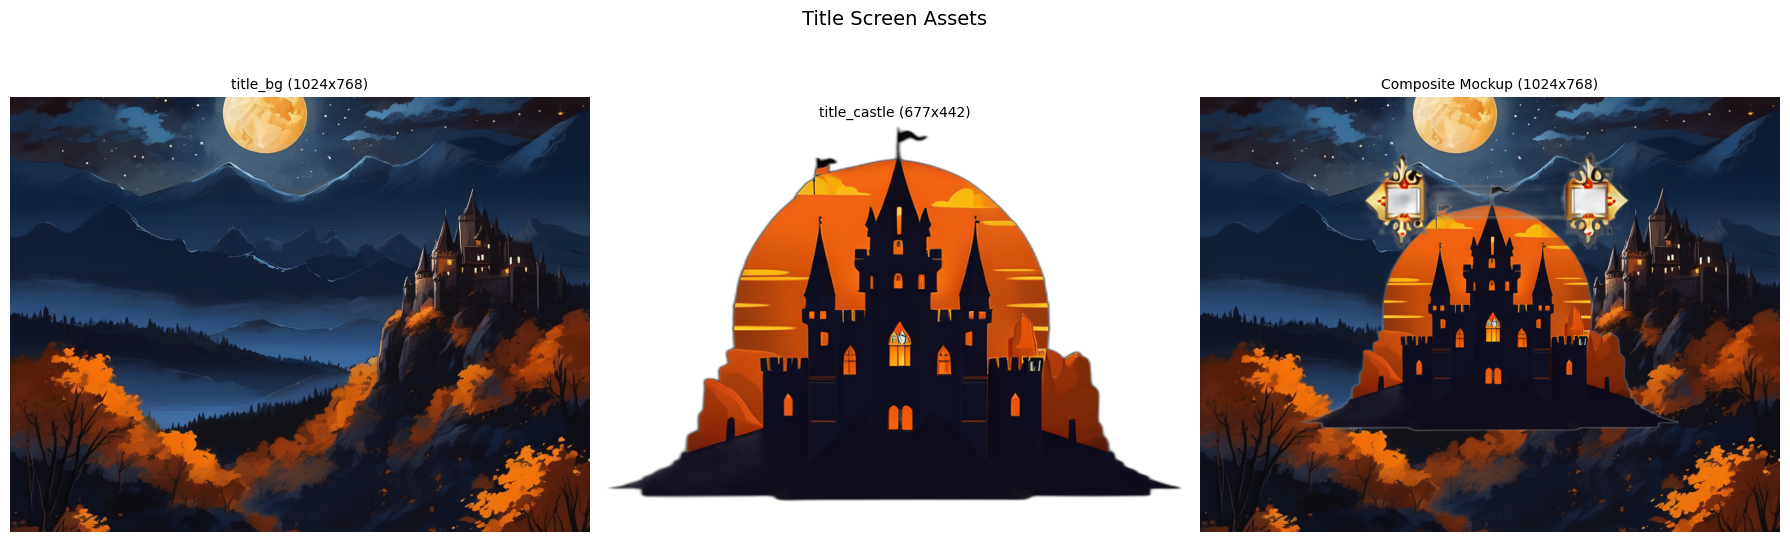

In [ ]:
import matplotlib.pyplot as plt

title_dir = OUTPUT_BASE / 'title'

bg_path = title_dir / 'title_bg.png'
castle_path = title_dir / 'title_castle.png'
logo_bg_path = title_dir / 'title_logo_bg.png'

if bg_path.exists():
    bg = Image.open(bg_path).convert('RGBA')
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    # 1. title_bg full
    axes[0].imshow(bg)
    axes[0].set_title(f'title_bg ({bg.size[0]}x{bg.size[1]})', fontsize=10)
    axes[0].axis('off')

    # 2. title_castle overlay
    if castle_path.exists():
        castle = Image.open(castle_path).convert('RGBA')
        axes[1].imshow(castle)
        axes[1].set_title(f'title_castle ({castle.size[0]}x{castle.size[1]})', fontsize=10)
        axes[1].axis('off')
    else:
        axes[1].text(0.5, 0.5, 'title_castle not found', ha='center', va='center')
        axes[1].axis('off')

    # 3. Composite mockup
    composite = bg.copy()
    if castle_path.exists():
        castle = Image.open(castle_path).convert('RGBA')
        # Place castle centered horizontally, near bottom
        cx = (composite.width - castle.width) // 2
        cy = composite.height - castle.height - 175
        composite.paste(castle, (cx, cy), castle)
    if logo_bg_path.exists():
        logo_bg = Image.open(logo_bg_path).convert('RGBA')
        lx = (composite.width - logo_bg.width) // 2
        ly = 80
        composite.paste(logo_bg, (lx, ly), logo_bg)

    axes[2].imshow(composite)
    axes[2].set_title('Composite Mockup (1024x768)', fontsize=10)
    axes[2].axis('off')

    plt.suptitle('Title Screen Assets', fontsize=14)
    plt.tight_layout()
    plt.show()
else:
    print('No title assets found yet — run generation cells first')

## Export

In [ ]:
import shutil

# Generate manifest
title_dir = OUTPUT_BASE / 'title'
manifest = {}

if title_dir.exists():
    keys = sorted(f.stem for f in title_dir.glob('*.png')
                  if not f.stem.startswith('_'))
    if keys:
        manifest['title_elements'] = keys

manifest_path = title_dir / 'manifest.json'
with open(manifest_path, 'w', encoding='utf-8') as f:
    json.dump(manifest, f, indent=2)

print('Manifest:')
for cat, keys in manifest.items():
    print(f'  {cat}: {len(keys)}')
print(f'  saved: {manifest_path}')

# Zip + download
zip_path = '/content/title_output'
shutil.make_archive(zip_path, 'zip', str(title_dir))
print(f'\nZip: {os.path.getsize(zip_path + ".zip") / 1024 / 1024:.1f} MB')

if ON_COLAB:
    from google.colab import files
    files.download(f'{zip_path}.zip')
else:
    print(f'Download: {zip_path}.zip')

Manifest:
  title_elements: 3
  saved: /content/drive/MyDrive/ai-rpg-game/outputs/title/manifest.json

Zip: 1.2 MB


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>